In [13]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
hours = np.array([2,4,6,8,10]).reshape(-1,1)
marks = np.array([55,60,70,80,88])

hours, marks

(array([[ 2],
        [ 4],
        [ 6],
        [ 8],
        [10]]),
 array([55, 60, 70, 80, 88]))

In [3]:
# Fit a Linear Regression Model (Closed-Form solver)
lin_reg = LinearRegression()
lin_reg.fit(hours, marks)

print("m: ", lin_reg.coef_[0])
print("c: ", lin_reg.intercept_)

m:  4.3
c:  44.8


In [8]:
# Compute the cost (MSE - mean square error) using a library
pred_marks = lin_reg.predict(hours)
mse = mean_squared_error(marks, pred_marks)

print("MSE for LinearRegression: ", mse)

MSE for LinearRegression:  1.5200000000000033


In [9]:
# Use a Gradient-Descent-Based Model - SDRegressor
sgd_reg = SGDRegressor(
    max_iter=1000,
    learning_rate="invscaling",
    eta0=0.01,
    random_state=42
)

sgd_reg.fit(hours, marks)
print("m: ", sgd_reg.coef_[0])
print("c: ", sgd_reg.intercept_[0])

pred_sgd = sgd_reg.predict(hours)
mse_sgd = mean_squared_error(marks, pred_sgd)
print("MSE for SGDRegressor: ", mse_sgd)

m:  5.698065492806587
c:  34.475265427340794
MSE for SGDRegressor:  20.906115830567398


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


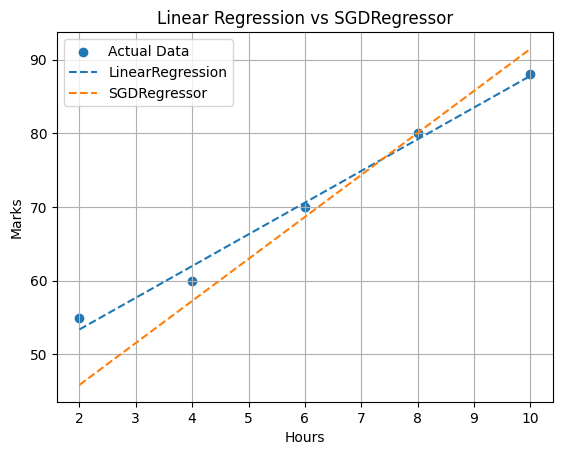

In [10]:
# Compare Both Lines Visually

plt.scatter(hours, marks, label = "Actual Data")

plt.plot(hours, pred_marks, label="LinearRegression", linestyle="--")
plt.plot(hours, pred_sgd, label="SGDRegressor", linestyle="--")

plt.xlabel("Hours")
plt.ylabel("Marks")
plt.title("Linear Regression vs SGDRegressor")
plt.legend()
plt.grid()
plt.show()

In [12]:
# Regression Evaluation Metrices

# Fit Linear Regression
model1 = LinearRegression()
model1.fit(hours,marks)

pred = model1.predict(hours)
print(pred)

[53.4 62.  70.6 79.2 87.8]


In [14]:
# Calculating MAE

mae = mean_absolute_error(marks, pred)
mse = mean_squared_error(marks, pred)
rmse = np.sqrt(mse)
r2 = r2_score(marks, pred)
print("MAE: ", mae)
print("MSE: ", mse)
print("RMSE: ", rmse)
print("R2: ", r2)

MAE:  1.040000000000002
MSE:  1.5200000000000033
RMSE:  1.2328828005937966
R2:  0.9898286937901499


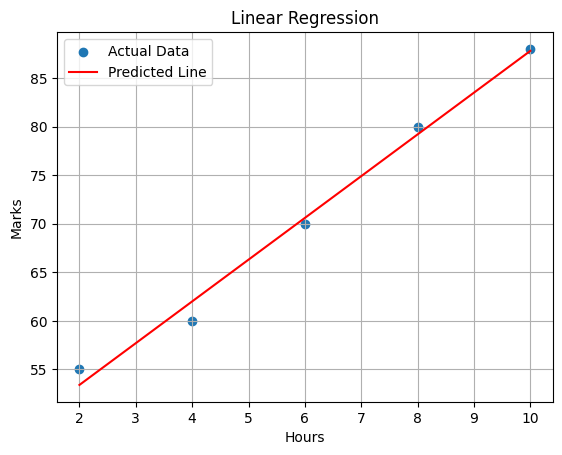

In [15]:
# Visualizing the fit

plt.scatter(hours, marks, label = "Actual Data")
plt.plot(hours, pred, color="red", label="Predicted Line")

plt.xlabel("Hours")
plt.ylabel("Marks")
plt.title("Linear Regression")
plt.legend()
plt.grid(True)
plt.show()
